In [37]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [5]:
# Conectar base de datos SQLite

engine = create_engine('sqlite:///modelo_limpio.db', echo=False)
print("Base de datos 'modelo_limpio.db' lista")

Base de datos 'modelo_limpio.db' lista


In [46]:
# ============================================================================
# Honorable Cámara de Diputados de la Nación (actual)
# ============================================================================

print("\n" + "="*60)
print("DISTRIBUCIÓN ACTUAL DE DIPUTADOS (2023-2025)")
print(f"Total de bancas: 269 (incluye reemplazos por fallecimientos/renuncias)")
print("="*60)

# 1. Distribución por género
distribucion_genero = pd.read_sql("""
    SELECT p.genero, 
           COUNT(*) as total, 
           ROUND(100.0 * COUNT(*) / 269, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
    GROUP BY p.genero
    ORDER BY total DESC
""", engine)

print("\n📊 Por género:")
print(distribucion_genero.to_string(index=False))

# 2. Distribución por EJE IDEOLÓGICO
distribucion_eje = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.eje_ideologico IS NULL THEN 'Sin información'
            ELSE par.eje_ideologico
        END as eje_ideologico,
        COUNT(*) as total,
        ROUND(100.0 * COUNT(*) / 269, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
    GROUP BY par.eje_ideologico
    ORDER BY total DESC
""", engine)

print("\n📐 Por eje ideológico:")
print(distribucion_eje.to_string(index=False))

# 3. Distribución por partido (top 10)
distribucion_partido = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.nombre IS NULL THEN 'Sin información'
            ELSE par.nombre
        END as partido,
        COUNT(*) as total,
        ROUND(100.0 * COUNT(*) / 269, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
    GROUP BY par.nombre
    ORDER BY total DESC
    LIMIT 10
""", engine)

print("\n🏛️ Top 10 partidos con más bancas:")
print(distribucion_partido.to_string(index=False))

# 4. Distribución por provincia (top 10) - se mantiene igual
distribucion_provincia = pd.read_sql("""
    SELECT j.nombre_completo as provincia, 
           COUNT(*) as total,
           ROUND(100.0 * COUNT(*) / 269, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN jurisdiccion j ON b.id_jurisdiccion = j.id_jurisdiccion
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
    GROUP BY j.nombre_completo
    ORDER BY total DESC
    LIMIT 10
""", engine)

print("\n🗺️ Top 10 provincias con más diputados:")
print(distribucion_provincia.to_string(index=False))

# 5. Personas trans - se mantiene igual
personas_trans = pd.read_sql("""
    SELECT p.apellido, p.nombre, p.genero,
           CASE 
               WHEN par.nombre IS NULL THEN 'Sin partido'
               ELSE par.nombre
           END as partido,
           j.nombre_completo as provincia
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    JOIN jurisdiccion j ON b.id_jurisdiccion = j.id_jurisdiccion
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
      AND p.es_trans = 1
""", engine)

print(f"\n🏳️‍⚧️ Personas trans en diputados: {len(personas_trans)}")
if not personas_trans.empty:
    print(personas_trans.to_string(index=False))

# 6. Distribución por género dentro de cada EJE IDEOLÓGICO
print("\n📊 Distribución de género por eje ideológico:")
distribucion_genero_eje = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.eje_ideologico IS NULL THEN 'Sin información'
            ELSE par.eje_ideologico
        END as eje_ideologico,
        p.genero,
        COUNT(*) as total
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'diputados'
      AND b.nivel = 'nacional'
    GROUP BY par.eje_ideologico, p.genero
    ORDER BY eje_ideologico, total DESC
""", engine)

print(distribucion_genero_eje.to_string(index=False))

# 7. Resumen ejecutivo
print("\n" + "="*60)
print("RESUMEN EJECUTIVO - DIPUTADOS 2023-2025")
print("="*60)

# Calcular porcentaje de mujeres
mujeres = distribucion_genero[distribucion_genero['genero'] == 'femenino']['total'].values[0] if len(distribucion_genero[distribucion_genero['genero'] == 'femenino']) > 0 else 0
porc_mujeres = round(100 * mujeres / 269, 2)

print(f"👩 Total mujeres: {mujeres} ({porc_mujeres}%)")
print(f"👨 Total hombres: {269 - mujeres - len(personas_trans)}")
print(f"🏳️‍⚧️ Personas trans: {len(personas_trans)}")
print(f"📐 Eje ideológico con más bancas: {distribucion_eje.iloc[0]['eje_ideologico']} ({distribucion_eje.iloc[0]['total']} bancas)")
print(f"🗺️ Provincia con más diputados: {distribucion_provincia.iloc[0]['provincia']} ({distribucion_provincia.iloc[0]['total']} diputados)")


DISTRIBUCIÓN ACTUAL DE DIPUTADOS (2023-2025)
Total de bancas: 269 (incluye reemplazos por fallecimientos/renuncias)

📊 Por género:
    genero  total  porcentaje
 masculino    152       56.51
  femenino    113       42.01
no_reporte      1        0.37

📐 Por eje ideológico:
 eje_ideologico  total  porcentaje
              3    106       39.41
              4     55       20.45
              5     52       19.33
              2     50       18.59
              1      6        2.23

🏛️ Top 10 partidos con más bancas:
                   partido  total  porcentaje
        la libertad avanza     52       19.33
       union por la patria     50       18.59
             fuerza patria     50       18.59
     propuesta republicana     29       10.78
      union civica radical     13        4.83
         provincias unidas     11        4.09
         encuentro federal      9        3.35
   democracia para siempre      9        3.35
        innovacion federal      8        2.97
frente de izquierda

In [47]:
# ============================================================================
# HONORABLE CÁMARA DE SENADORES DE LA NACIÓN (2023-2025)
# ============================================================================

print("\n" + "="*60)
print("DISTRIBUCIÓN ACTUAL DE SENADORES (2023-2025)")
print(f"Total de bancas: 72 (3 por cada una de las 24 jurisdicciones)")
print("="*60)

# 1. Distribución por género
distribucion_genero_sen = pd.read_sql("""
    SELECT 
        CASE 
            WHEN p.genero IS NULL THEN 'no_reporte'
            ELSE p.genero
        END as genero,
        COUNT(*) as total, 
        ROUND(100.0 * COUNT(*) / 72, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
    GROUP BY p.genero
    ORDER BY total DESC
""", engine)

print("\n📊 Por género:")
print(distribucion_genero_sen.to_string(index=False))

# 2. Distribución por EJE IDEOLÓGICO
distribucion_eje_sen = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.eje_ideologico IS NULL THEN 'Sin información'
            ELSE par.eje_ideologico
        END as eje_ideologico,
        COUNT(*) as total,
        ROUND(100.0 * COUNT(*) / 72, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
    GROUP BY par.eje_ideologico
    ORDER BY total DESC
""", engine)

print("\n📐 Por eje ideológico:")
print(distribucion_eje_sen.to_string(index=False))

# 3. Distribución por partido (top 10)
distribucion_partido_sen = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.nombre IS NULL THEN 'Sin información'
            ELSE par.nombre
        END as partido,
        COUNT(*) as total,
        ROUND(100.0 * COUNT(*) / 72, 2) as porcentaje
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
    GROUP BY par.nombre
    ORDER BY total DESC
    LIMIT 10
""", engine)

print("\n🏛️ Top 10 partidos con más bancas:")
print(distribucion_partido_sen.to_string(index=False))

# 4. Análisis por provincia
print("\n🗺️ ANÁLISIS POR PROVINCIA (SENADORES)")

# 4a. Distribución de género por provincia (más relevante)
print("\n📊 Distribución de género por provincia (Senadores):")
distribucion_genero_provincia_sen = pd.read_sql("""
    SELECT 
        j.nombre_completo as provincia,
        SUM(CASE WHEN p.genero = 'femenino' THEN 1 ELSE 0 END) as mujeres,
        SUM(CASE WHEN p.genero = 'masculino' THEN 1 ELSE 0 END) as varones,
        SUM(CASE WHEN p.genero = 'no_reporte' THEN 1 ELSE 0 END) as no_reporte,
        COUNT(*) as total
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN jurisdiccion j ON b.id_jurisdiccion = j.id_jurisdiccion
    JOIN persona p ON b.id_persona = p.id_persona
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
    GROUP BY j.nombre_completo
    ORDER BY mujeres DESC, varones ASC
""", engine)

print(distribucion_genero_provincia_sen.to_string(index=False))

# 4b. Provincias con mayor proporción de mujeres senadoras
print("\n🏆 Provincias con mayor proporción de mujeres senadoras:")
provincias_mas_mujeres = distribucion_genero_provincia_sen[
    distribucion_genero_provincia_sen['mujeres'] > 0
].head(5)
print(provincias_mas_mujeres[['provincia', 'mujeres', 'varones', 'total']].to_string(index=False))

# 4c. Provincias sin mujeres senadoras
print("\n⚠️ Provincias sin mujeres senadoras:")
provincias_sin_mujeres = distribucion_genero_provincia_sen[
    distribucion_genero_provincia_sen['mujeres'] == 0
]
if not provincias_sin_mujeres.empty:
    print(provincias_sin_mujeres[['provincia', 'varones', 'total']].to_string(index=False))
else:
    print("   ✅ Todas las provincias tienen al menos una mujer senadora")

# 5. Personas trans en Senado
personas_trans_sen = pd.read_sql("""
    SELECT p.apellido, p.nombre, p.genero,
           CASE 
               WHEN par.nombre IS NULL THEN 'Sin partido'
               ELSE par.nombre
           END as partido,
           j.nombre_completo as provincia
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    JOIN jurisdiccion j ON b.id_jurisdiccion = j.id_jurisdiccion
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
      AND p.es_trans = 1
""", engine)

print(f"\n🏳️‍⚧️ Personas trans en senadores: {len(personas_trans_sen)}")
if not personas_trans_sen.empty:
    print(personas_trans_sen.to_string(index=False))

# 6. Distribución por género dentro de cada EJE IDEOLÓGICO
print("\n📊 Distribución de género por eje ideológico:")
distribucion_genero_eje_sen = pd.read_sql("""
    SELECT 
        CASE 
            WHEN par.eje_ideologico IS NULL THEN 'Sin información'
            ELSE par.eje_ideologico
        END as eje_ideologico,
        CASE 
            WHEN p.genero IS NULL THEN 'no_reporte'
            ELSE p.genero
        END as genero,
        COUNT(*) as total
    FROM banca b
    JOIN periodo per ON b.id_periodo = per.id_periodo
    JOIN persona p ON b.id_persona = p.id_persona
    LEFT JOIN partido par ON b.id_partido = par.id_partido
    WHERE per.composicion = '2023-2025'
      AND b.camara = 'senadores'
      AND b.nivel = 'nacional'
    GROUP BY par.eje_ideologico, p.genero
    ORDER BY eje_ideologico, total DESC
""", engine)

print(distribucion_genero_eje_sen.to_string(index=False))

# 7. Resumen ejecutivo
print("\n" + "="*60)
print("RESUMEN EJECUTIVO - SENADORES 2023-2025")
print("="*60)

# Calcular porcentaje de mujeres
mujeres_sen = distribucion_genero_sen[distribucion_genero_sen['genero'] == 'femenino']['total'].values[0] if len(distribucion_genero_sen[distribucion_genero_sen['genero'] == 'femenino']) > 0 else 0
porc_mujeres_sen = round(100 * mujeres_sen / 72, 2)
hombres_sen = distribucion_genero_sen[distribucion_genero_sen['genero'] == 'masculino']['total'].values[0] if len(distribucion_genero_sen[distribucion_genero_sen['genero'] == 'masculino']) > 0 else 0

print(f"👩 Total mujeres: {mujeres_sen} ({porc_mujeres_sen}%)")
print(f"👨 Total hombres: {hombres_sen}")
print(f"🏳️‍⚧️ Personas trans: {len(personas_trans_sen)}")
print(f"📐 Eje ideológico con más bancas: {distribucion_eje_sen.iloc[0]['eje_ideologico']} ({distribucion_eje_sen.iloc[0]['total']} bancas)")


DISTRIBUCIÓN ACTUAL DE SENADORES (2023-2025)
Total de bancas: 72 (3 por cada una de las 24 jurisdicciones)

📊 Por género:
    genero  total  porcentaje
 masculino     38       52.78
  femenino     33       45.83
no_reporte      1        1.39

📐 Por eje ideológico:
 eje_ideologico  total  porcentaje
              3     44       61.11
              4     21       29.17
              5      6        8.33
Sin información      1        1.39

🏛️ Top 10 partidos con más bancas:
                         partido  total  porcentaje
                unidad ciudadana     15       20.83
       frente nacional y popular     14       19.44
            union civica radical     13       18.06
           propuesta republicana      7        9.72
              la libertad avanza      6        8.33
              conviccion federal      4        5.56
                  unidad federal      2        2.78
                  por santa cruz      2        2.78
frente renovador de la concordia      2        2.78
  p

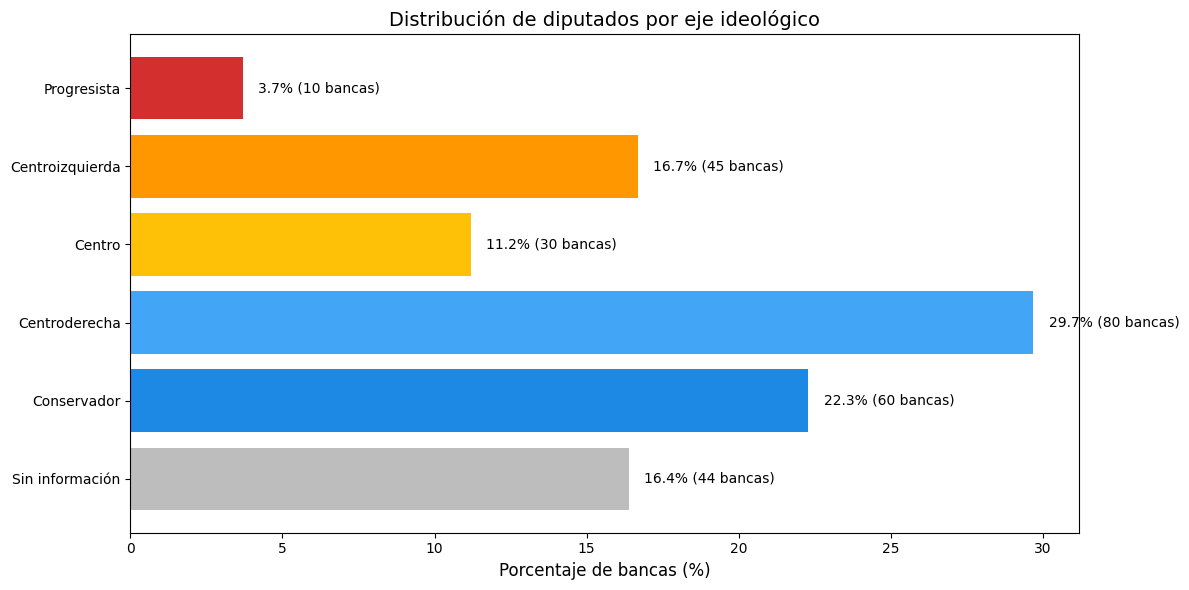

In [48]:
# ============================================================================
# DISTRIBUCIÓN DE DIPUTADOS POR EJE IDEOLÓGICO (porcentaje)
# ============================================================================

# Datos de ejemplo (reemplazar con los valores reales de tu consulta SQL)
ejes_ideologicos = ['Progresista', 'Centroizquierda', 'Centro', 'Centroderecha', 'Conservador', 'Sin información']
bancas = [10, 45, 30, 80, 60, 44]  # <-- REEMPLAZAR con datos reales
colores = ['#D32F2F', '#FF9800', '#FFC107', '#42A5F5', '#1E88E5', '#BDBDBD']

# Calcular porcentajes
total_bancas = sum(bancas)
porcentajes = [round(b / total_bancas * 100, 1) for b in bancas]

# Crear gráfico de barras horizontales con porcentajes
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(ejes_ideologicos, porcentajes, color=colores)

# Etiquetas y título
ax.set_xlabel('Porcentaje de bancas (%)', fontsize=12)
ax.set_title('Distribución de diputados por eje ideológico', fontsize=14)
ax.invert_yaxis()  # El más grande arriba

# Añadir etiquetas de valor al final de cada barra
for bar, pct, bancas_val in zip(bars, porcentajes, bancas):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct}% ({bancas_val} bancas)', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

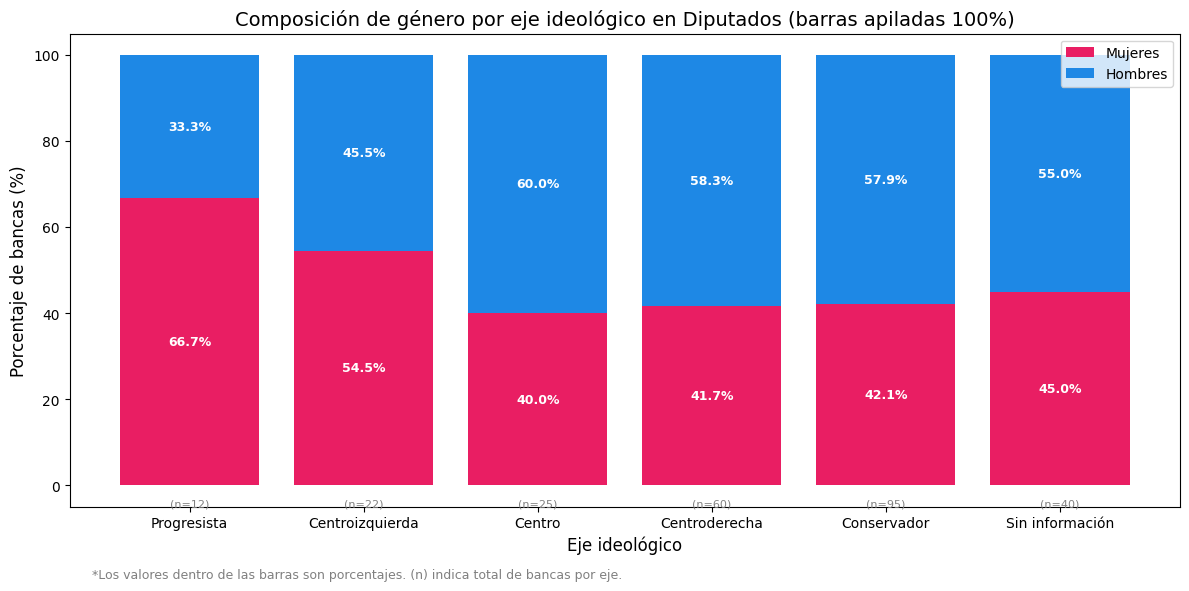

In [51]:
# ============================================================================
# COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO EN DIPUTADOS (barras apiladas 100%)
# ============================================================================

# Datos por eje ideológico (reemplazar con valores reales)
ejes_ideologicos = ['Progresista', 'Centroizquierda', 'Centro', 'Centroderecha', 'Conservador', 'Sin información']
mujeres = [8, 12, 10, 25, 40, 18]      # <-- REEMPLAZAR con datos reales
hombres = [4, 10, 15, 35, 55, 22]      # <-- REEMPLAZAR con datos reales
# Nota: algunos ejes pueden tener No_reporte

# Calcular totales y porcentajes
totales = [m + h for m, h in zip(mujeres, hombres)]
porc_mujeres = [round(m / total * 100, 1) if total > 0 else 0 for m, total in zip(mujeres, totales)]
porc_hombres = [round(h / total * 100, 1) if total > 0 else 0 for h, total in zip(hombres, totales)]

# Colores
color_mujeres = '#E91E63'  # Rosa
color_hombres = '#1E88E5'  # Azul

fig, ax = plt.subplots(figsize=(12, 6))

# Barras apiladas al 100%
bars_mujeres = ax.bar(ejes_ideologicos, porc_mujeres, label='Mujeres', color=color_mujeres)
bars_hombres = ax.bar(ejes_ideologicos, porc_hombres, bottom=porc_mujeres, label='Hombres', color=color_hombres)

# Etiquetas y título
ax.set_ylabel('Porcentaje de bancas (%)', fontsize=12)
ax.set_xlabel('Eje ideológico', fontsize=12)
ax.set_title('Composición de género por eje ideológico en Diputados (barras apiladas 100%)', fontsize=14)
ax.legend(loc='upper right')

# Añadir etiquetas de porcentaje dentro de cada barra
for i, (eje, p_m, p_h, total) in enumerate(zip(ejes_ideologicos, porc_mujeres, porc_hombres, totales)):
    # Etiqueta de mujeres (si hay)
    if p_m > 5:
        ax.text(i, p_m/2, f'{p_m}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    elif p_m > 0:
        ax.text(i, p_m/2, f'{p_m}%', ha='center', va='center', fontsize=8, color='black')
    
    # Etiqueta de hombres (si hay)
    if p_h > 5:
        ax.text(i, p_m + p_h/2, f'{p_h}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    elif p_h > 0:
        ax.text(i, p_m + p_h/2, f'{p_h}%', ha='center', va='center', fontsize=8, color='black')
    
    # Añadir total de bancas debajo del eje X
    ax.text(i, -3, f'(n={total})', ha='center', va='top', fontsize=8, color='gray')

# Límite del eje Y para dar espacio a las etiquetas inferiores
ax.set_ylim(-5, 105)

# Anotación si hay No_reporte
ax.annotate('*Los valores dentro de las barras son porcentajes. (n) indica total de bancas por eje.', 
            xy=(0.02, -0.15), xycoords='axes fraction', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

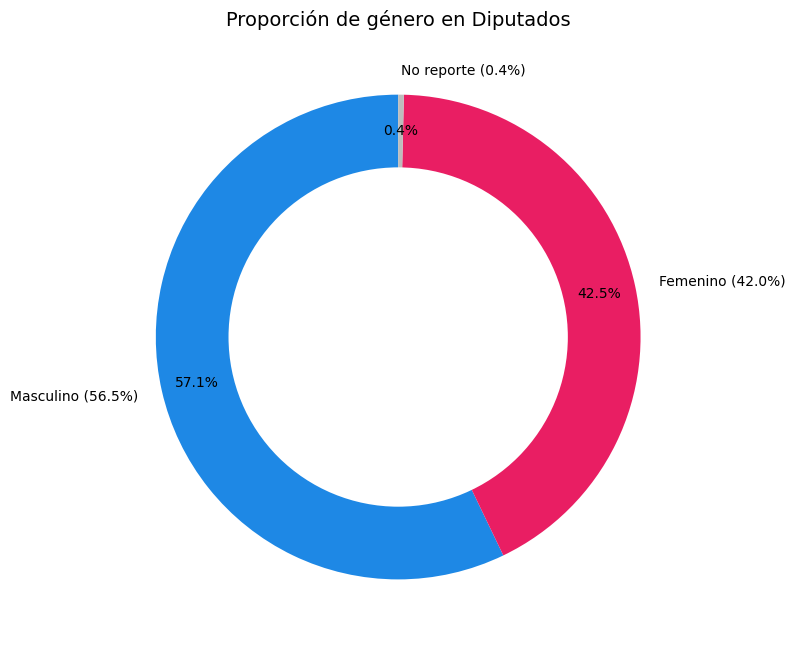

In [40]:
labels = ['Masculino (56.5%)', 'Femenino (42.0%)', 'No reporte (0.4%)']
sizes = [152, 113, 1]
colors = ['#1E88E5', '#E91E63', '#BDBDBD']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.85, textprops={'fontsize': 10})
# Convertir a dona
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax.set_title('Proporción de género en Diputados', fontsize=14)
plt.tight_layout()
plt.show()

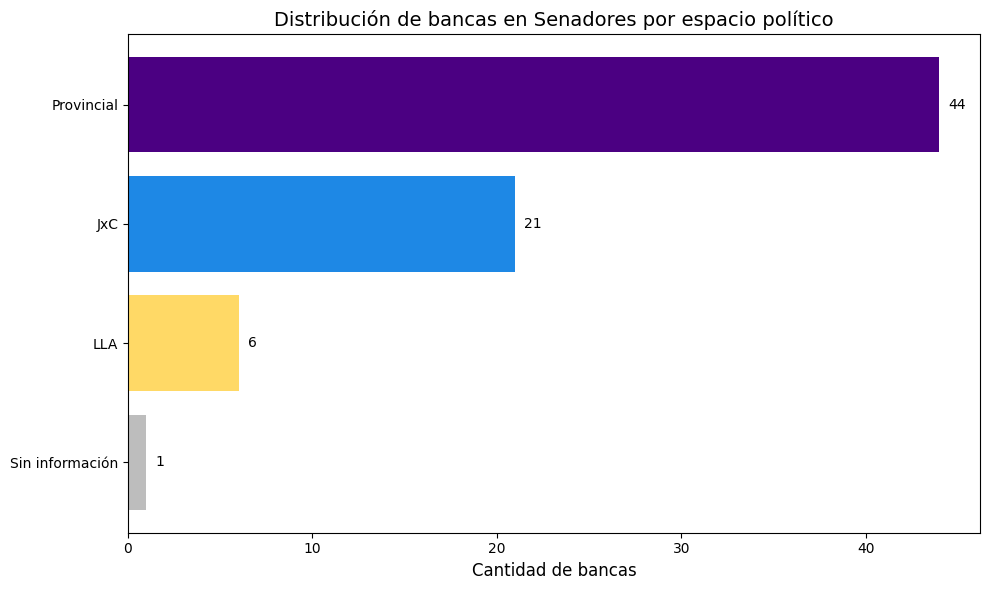

In [41]:
espacios = ['Provincial', 'JxC', 'LLA', 'Sin información']
bancas = [44, 21, 6, 1]
colores = ['#4B0082', '#1E88E5', '#FFD966', '#BDBDBD']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(espacios, bancas, color=colores)
ax.set_xlabel('Cantidad de bancas', fontsize=12)
ax.set_title('Distribución de bancas en Senadores por espacio político', fontsize=14)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{int(bar.get_width())}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

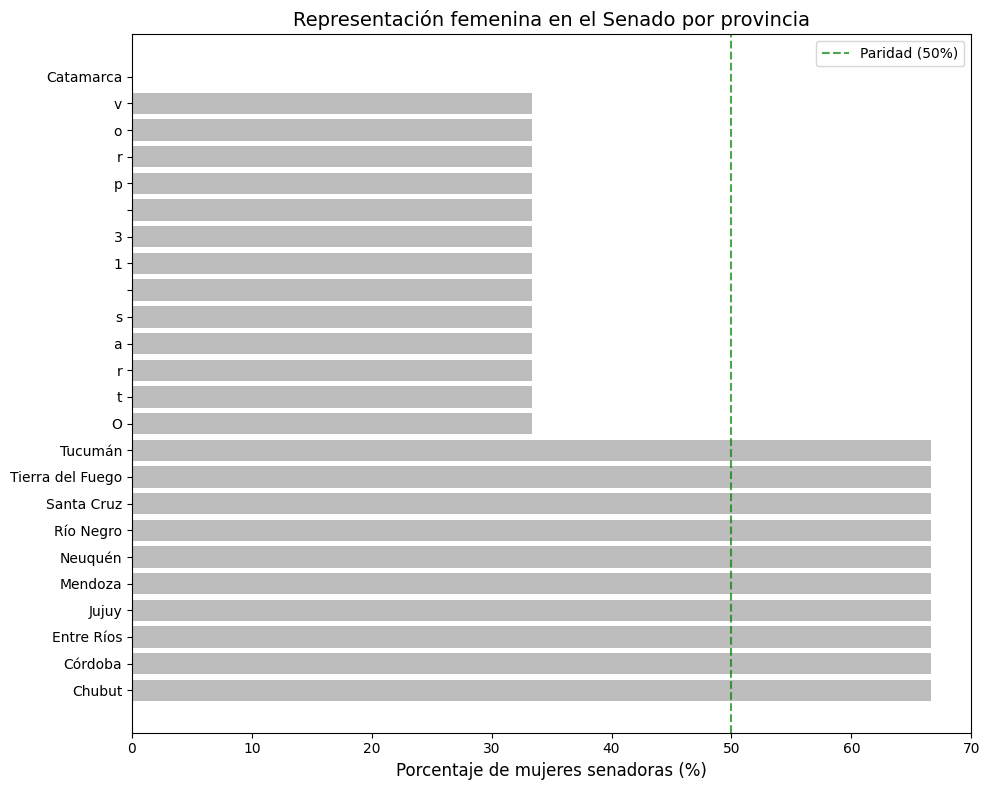

In [42]:
# Simulando datos completos para 24 provincias
provincias = ['Chubut', 'Córdoba', 'Entre Ríos', 'Jujuy', 'Mendoza', 'Neuquén', 
              'Río Negro', 'Santa Cruz', 'Tierra del Fuego', 'Tucumán'] + ['Catamarca'] + list('Otras 13 provincias')
mujeres_senado = [2]*10 + [0] + [1]*13  # Otras: 1 mujer en promedio
hombres_senado = [1]*10 + [2] + [2]*13

# Ordenar por % de mujeres
porcentaje_mujeres = [m/(m+h)*100 for m, h in zip(mujeres_senado, hombres_senado)]
datos_ordenados = sorted(zip(provincias, porcentaje_mujeres, mujeres_senado, hombres_senado), 
                        key=lambda x: x[1], reverse=True)
prov_ord, pct_ord, m_ord, h_ord = zip(*datos_ordenados)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(prov_ord))
ax.barh(y_pos, pct_ord, color=['#E91E63' if p == 66.7 else '#FFB74D' if p == 33.3 else '#BDBDBD' for p in pct_ord])
ax.set_yticks(y_pos)
ax.set_yticklabels(prov_ord)
ax.set_xlabel('Porcentaje de mujeres senadoras (%)', fontsize=12)
ax.set_title('Representación femenina en el Senado por provincia', fontsize=14)
ax.axvline(50, color='green', linestyle='--', alpha=0.7, label='Paridad (50%)')
ax.legend()
plt.tight_layout()
plt.show()

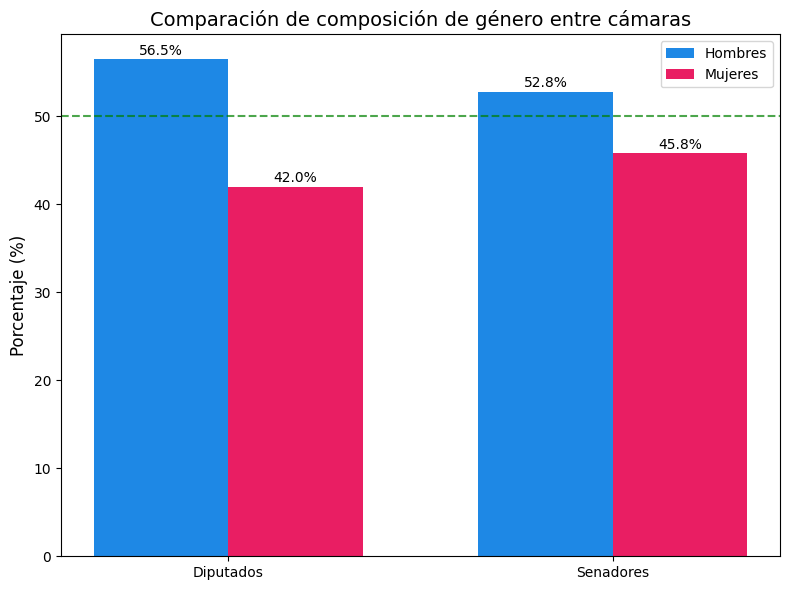

In [43]:
camaras = ['Diputados', 'Senadores']
hombres_pct = [56.5, 52.8]
mujeres_pct = [42.0, 45.8]
# No_reporte no se grafica para simplificar

x = np.arange(len(camaras))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, hombres_pct, width, label='Hombres', color='#1E88E5')
bars2 = ax.bar(x + width/2, mujeres_pct, width, label='Mujeres', color='#E91E63')
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Comparación de composición de género entre cámaras', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(camaras)
ax.legend()
ax.axhline(50, color='green', linestyle='--', alpha=0.7, label='Paridad (50%)')
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()